In [ ]:
#%%

# %load_ext autoreload
# %autoreload 2

import os
from selfmod import *


############# Contextual Self-Modulation #############

Jax version: 0.4.28
Available devices: [cuda(id=0)]


In [ ]:
#%%

## For reproducibility
seed = 2026

## Dataloader hps
num_envs = (9*28, 4*28)
num_shots = (-1, -1)
num_workers = 0
shuffle = False
train_proportion = 0.1  ## Min proporrion of the trajectory for training
test_proportion = 1.0

## Learner/model hps
context_pool_size = 4
context_size = 64*8
taylor_orders = (2, 0)
ivp_args = {"return_traj":True, "max_steps":1024*1, "dt_min":1e-2}
skip_steps = 5
loss_contributors = 8
max_ret_env_states = 252

## Train and adapt hps
init_lrs = (5e-4, 5e-4)
sched_factor = 1.
max_train_batches = 1
max_adapt_batches = 1

nb_outer_steps = 4000
nb_inner_steps = (20, 20)
nb_adapt_epochs = 1000
validate_every = 150

print_error_every = (100, 100)

meta_train = False
save_trainer = True
meta_test = True

run_folder = "./runs/241017-154559-W-2Hours-Good/"
# run_folder = None
data_folder = "./data_2D/"

In [ ]:
#%%

if run_folder==None:
    run_folder = make_run_folder('./runs/')
else:
    print("Using existing run folder:", run_folder)

adapt_folder = setup_run_folder(run_folder, os.path.basename(__file__))

Using existing run folder: ./runs/241017-154559-W-2Hours-Good/
Completed copied scripts 


In [ ]:
#%%

## Define 4 keys for dataloader(s), learner(s), trainer(s) and visualtester(s)
mother_key = jax.random.PRNGKey(seed)
data_key, model_key, trainer_key, test_key = jax.random.split(mother_key, num=4)

train_dataloader = NumpyLoader(ODEBenchDataset(data_dir=data_folder+"train.npz", 
                                               norm_consts=data_folder+"train_bounds.npy",   ## since more data in test/val sets
                                               num_shots=num_shots[0], 
                                               skip_steps=skip_steps,
                                               traj_prop_min=train_proportion), 
                              batch_size=num_envs[0],
                              shuffle=shuffle,
                              num_workers=num_workers,
                              drop_last=False)

val_dataloader = NumpyLoader(ODEBenchDataset(data_dir=data_folder+"test.npz", 
                                             norm_consts=data_folder+"train_bounds.npy",
                                             num_shots=num_shots[1], 
                                             skip_steps=skip_steps,
                                             traj_prop_min=test_proportion),
                              batch_size=num_envs[0],
                              shuffle=shuffle,
                              num_workers=num_workers,
                              drop_last=False)

# ins, outs = next(iter(train_dataloader))
# ins.shape, outs.shape

In [ ]:
#%%

# # ## Plot all trajectories in the first 9 environments
# # plt_data = train_dataloader.dataset.dataset
# # plt_t = train_dataloader.dataset.t_eval

# ## Alternative way to gather the data
# (ins, ts), outs = next(iter(train_dataloader))
# plt_data = outs
# plt_t = ts

# print("Shapes of data and t_eval:", plt_data.shape, plt_t.shape)

# E_plot = 5
# E_ = 9

# fig, ax = plt.subplots(E_plot, 1, figsize=(6, E_plot*3))
# if E_plot==1:
#     ax = [ax]
# colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple']
# for e in range(E_plot):
#     e_plot_data = plt_data[e*E_:(e+1)*E_, :, :, 0]
#     e_t_eval = plt_t[e*E_:(e+1)*E_]
#     for e_ in range(E_):
#         # ax[e].plot(e_plot_data[e_].T, '-', color=colors[e_])
#         ax[e].plot(e_t_eval[e_], e_plot_data[e_].T, '-', color=colors[e_])
#         # if e==1:
#         #     print("t_eval is:", e_t_eval[e_])
#     ax[e].set_title(f"Environment {23+e}")
#     ax[e].set_xlabel("time")
#     ax[e].set_ylabel("y_0")

# plt.tight_layout()
# plt.show()

In [ ]:
#%%

# ## Define model and loss function for the learner
class MultiMLP(eqx.Module):
    layers_data: list
    activations_data: list
    layers_main: list
    activations_main: list

    ctx_utils:any
    depth_data:int
    depth_main:int

    def __init__(self, data_size, hidden_size, depth_data, depth_main, context_size, ctx_utils=None, key=None):
        self.ctx_utils = ctx_utils
        self.depth_data = depth_data
        self.depth_main = depth_main

        layer_ctx_size = context_size//depth_main  ## Size of the context to modulate each shared/main layer
        assert context_size%depth_main==0, "Context size must be divisible by the depth of the main network"

        keys = jax.random.split(key, num=depth_data+depth_main+2)
        self.activations_data = [Swish(key=k) for k in keys[:depth_data]]
        self.activations_main = [Swish(key=k) for k in keys[depth_data+2:]]

        self.layers_data = [eqx.nn.Linear(0+data_size, hidden_size, key=keys[0])]
        self.layers_data += [eqx.nn.Linear(hidden_size, hidden_size, key=keys[i]) for i in range(1, depth_data)]
        self.layers_data += [eqx.nn.Linear(hidden_size, layer_ctx_size, key=keys[depth_data])]

        self.layers_main = [eqx.nn.Linear(2*layer_ctx_size, hidden_size, key=keys[depth_data+1])]
        self.layers_main += [eqx.nn.Linear(hidden_size+layer_ctx_size, hidden_size, key=keys[depth_data+i+1]) for i in range(1, depth_main)]
        self.layers_main += [eqx.nn.Linear(hidden_size, data_size, key=keys[depth_data+depth_main+1])]

        assert len(self.layers_data) == len(self.activations_data)+1, f"Total number of layers {len(self.layers_data)} and activations {len(self.activations_data)} mismatch in the data network"
        assert len(self.layers_main) == len(self.activations_main)+1, f"Total number of layers {len(self.layers_main)} and activations {len(self.activations_main)} mismatch in the main network"


    def __call__(self, t, y, ctx_arr):
    
        # ctx_shapes, ctx_treedef, ctx_static, _ = self.ctx_utils
        # ctx_params = unflatten_pytree(ctx_arr, ctx_shapes, ctx_treedef)
        # ctx_fun = eqx.combine(ctx_params, ctx_static)

        # t_arr = jnp.array([t])
        # ctx = ctx_fun(t_arr)

        ctx = ctx_arr

        ## Split the context into parts for each layer
        ctx_parts = jnp.split(ctx[:], self.depth_main, axis=0)

        # y = jnp.concatenate([t_arr, y], axis=0)
        for layer, activation in zip(self.layers_data[:-1], self.activations_data):
            y = activation(layer(y))
        y = self.layers_data[-1](y)

        ## Apply the context at each layer (except the very last)
        for layer, activation, ctx_part in zip(self.layers_main[:-1], self.activations_main, ctx_parts):
            y = jnp.concatenate([y, ctx_part], axis=0)
            y = activation(layer(y))
        y = self.layers_main[-1](y)

        return y




def env_loss_fn(model, ctx, y_hat, y):
    """
    Loss function for one environment. Leading dimension of y_hat corresponds to the pool size !
    """

    term1 = jnp.mean((y_hat-y)**2)
    # term2 = jnp.mean(jnp.abs(ctx))
    # term3 = params_norm_squared(model)

    # loss_val = term1 + 1e-3*term2 + 1e-3*term3
    loss_val = term1

    return loss_val, (term1, 0., 0.)

## Example context to use
# contexts = InfDimContextParams(nb_envs=num_envs[0], 
#                                 input_dim=1,
#                                 output_dim=context_size,
#                             hidden_size=32, 
#                             depth=2, 
#                             activation=Swish(key=model_key),
#                             key=None)
contexts = ArrayContextParams(nb_envs=num_envs[0], context_size=context_size)

neuralnet = MultiMLP(data_size=2,
                     hidden_size=64, 
                     depth_data=2,
                     depth_main=8,
                     context_size=context_size,
                    #  ctx_utils=contexts.ctx_utils,
                     key=model_key) 

model = NeuralODE(neuralnet=neuralnet,
                    taylor_order=taylor_orders[0],
                    ivp_args=ivp_args,
                    t_eval=None,    ## t_eval is provided with each model call
                    taylor_ad_mode="forward")

learner = Learner(model=model,
                context_size=contexts.eff_context_size, 
                context_pool_size=context_pool_size,
                env_loss_fn=env_loss_fn, 
                contexts=contexts,
                reuse_contexts=True,
                loss_contributors=loss_contributors,
                pool_filling="NF",
                loss_filling="NF-W",        ## Weighted negative filling, inversely proportional to the loss
                key=model_key)


model_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)) if x is not None)
print("\n\nTotal number of parameters in the model:", model_params)
print("Total number of parameters in one context:", contexts.eff_context_size)


Using 8 environments to estimate the global training loss function ...


Total number of parameters in the model: 74700
Total number of parameters in one context: 512


In [ ]:
#%%

## Define optimiser and train the model
init_lr_model, init_lr_ctx = init_lrs
total_steps = nb_outer_steps*nb_inner_steps[0]
bd_scales = {total_steps//3:sched_factor, 2*total_steps//3:sched_factor}
sched_model = optax.piecewise_constant_schedule(init_value=init_lr_model, boundaries_and_scales=bd_scales)
# opt_model = optax.adam(sched_model)
opt_model = optax.chain(optax.clip(5.0), optax.adam(sched_model))

opt_ctx = optax.adam(init_lr_ctx)

trainer = NCFTrainer(learner, (opt_model, opt_ctx), key=trainer_key)

In [ ]:
#%%

## Meta-training
if meta_train == True:
    trainer_save_path = run_folder if save_trainer == True else False
    trainer.meta_train(dataloader=train_dataloader, 
                        nb_epochs=1, 
                        nb_outer_steps=nb_outer_steps, 
                        nb_inner_steps=nb_inner_steps, 
                        inner_tols=(1e-16, 1e-16), 
                        proximal_betas=(10., 10.), 
                        max_train_batches=max_train_batches, 
                        print_error_every=print_error_every, 
                        save_checkpoints=True,
                        validate_every=validate_every, 
                        save_path=trainer_save_path, 
                        # val_dataloader=val_dataloader, 
                        val_nb_steps=nb_adapt_epochs,
                        val_criterion_id=0, 
                        max_val_batches=max_train_batches,
                        key=trainer_key)
else:
    restore_folder = run_folder
    trainer.restore_trainer(path=run_folder)


No training, loading model and results from ./runs/241017-154559-W-2Hours-Good/ folder ...



In [ ]:
#%%

## Test and visualise the results on a test dataloader
visualtester = DynamicsVisualTester(trainer, key=test_key)

# ind_crit, all_ind_crit = visualtester.evaluate(train_dataloader, 
#                                     taylor_order=taylor_orders[1], 
#                                     nb_steps=nb_adapt_epochs,
#                                     print_error_every=print_error_every, 
#                                     criterion_id=0,
#                                     verbose=True,
#                                     val_dataloader=val_dataloader,
#                                     max_ret_env_states=max_ret_env_states,
#                                     max_adapt_batches=max_adapt_batches,
#                                     stochastic=False)

# visualtester.visualize_artefacts(save_path=run_folder+"artefacts.png")
# print("Loss per InD environment:", all_ind_crit[0].tolist())



# new_ctx = np.load(run_folder+"contexts_params.npy")
# learner.contexts = eqx.tree_at(lambda c:c.params, learner.contexts, new_ctx)
# eqx.tree_serialise_leaves(run_folder+"contexts.eqx", learner.contexts)


==  Begining context clusters visualisation with t-SNE ... ==
    Visualising the parameters (either vectors or function weights)
    Visualising predictions from the contexts (reconstituted as functions)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saving context clusters in: ./runs/241017-154559-W-2Hours-Good/context_clusters.png


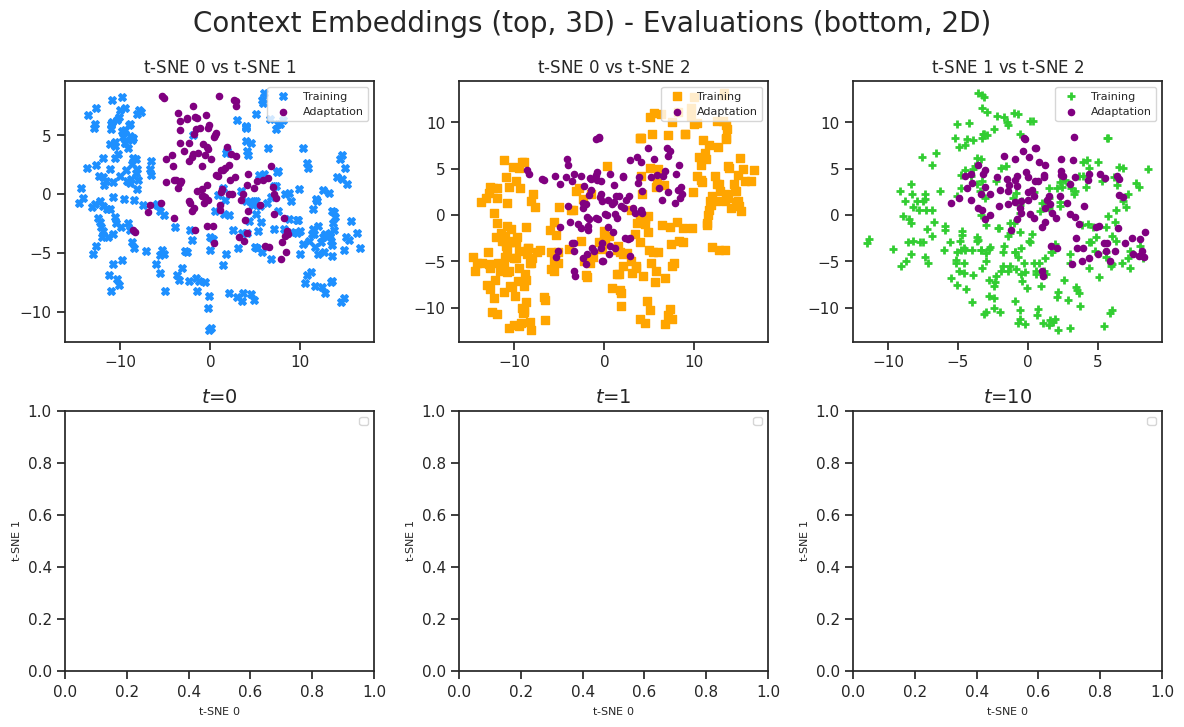

In [ ]:
#%%

visualtester.visualize_context_clusters(perplexities=(25, 20),
                                        # key=test_key,
                                        key=jax.random.PRNGKey(time.time_ns()),
                                        save_path=run_folder+"context_clusters.png")

In [ ]:
#%%

## After training, copy nohup.log to the runfolder
try:
    __IPYTHON__ ## in a jupyter notebook
except NameError:
    os.system(f"cp nohup.log {run_folder}")

In [ ]:
#%%

# adapt_dataloader_test.dataset.dataset.max()
train_dataloader.dataset.dataset.max()
# val_dataloader.dataset.dataset.max()

1.0


==  Begining in-domain dynamics visualisation ... ==
    Trajectory id: 0
    Visualized dimensions: (0, 1)
Testing finished. Figure saved in: ./runs/241017-154559-W-2Hours-Good/dynamics.png


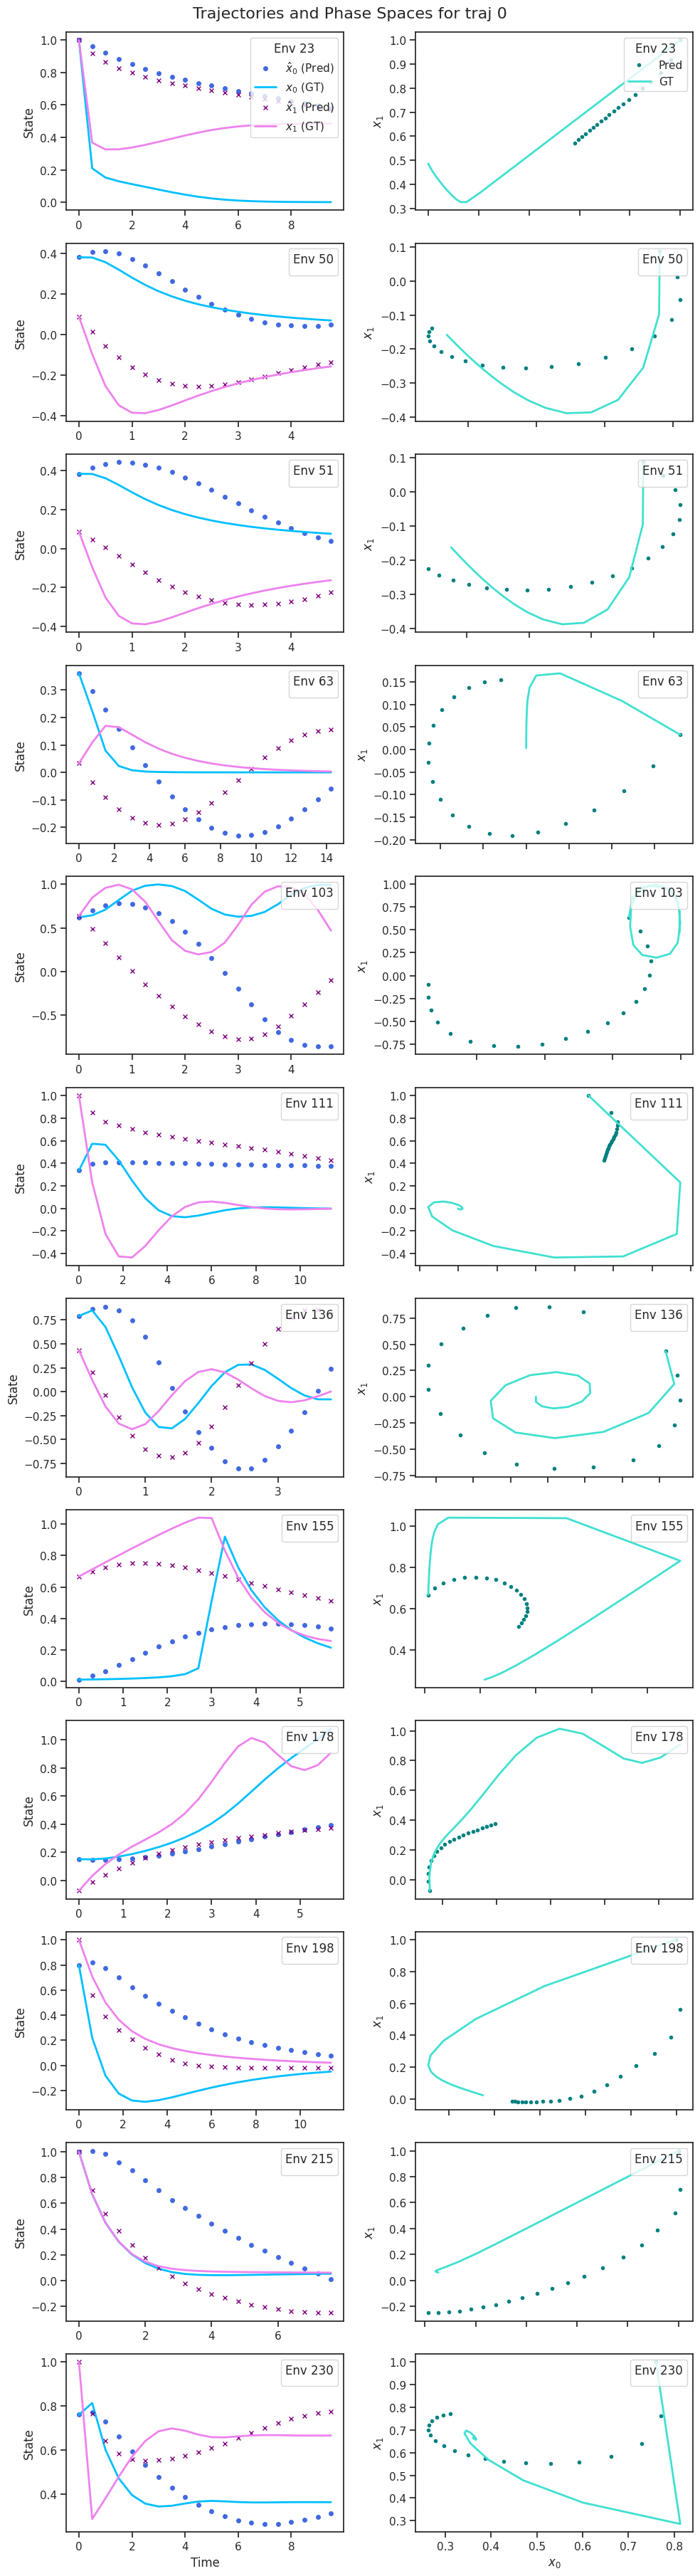

In [ ]:
#%%

visualtester.visualize_dynamics(save_path=run_folder+"dynamics.png",
                                data_loader=val_dataloader,
                                # nb_envs=10,
                                envs=[23, 50, 51, 63, 103, 111, 136, 155, 178, 198, 215, 230],
                                traj=0,
                                share_axes=False,
                                key=test_key)


==  Begining in-domain dynamics visualisation ... ==
    Trajectory id: 0
    Visualized dimensions: (0, 1)
Testing finished. Figure saved in: ./runs/241017-154559-W-2Hours-Good/dynamics.png


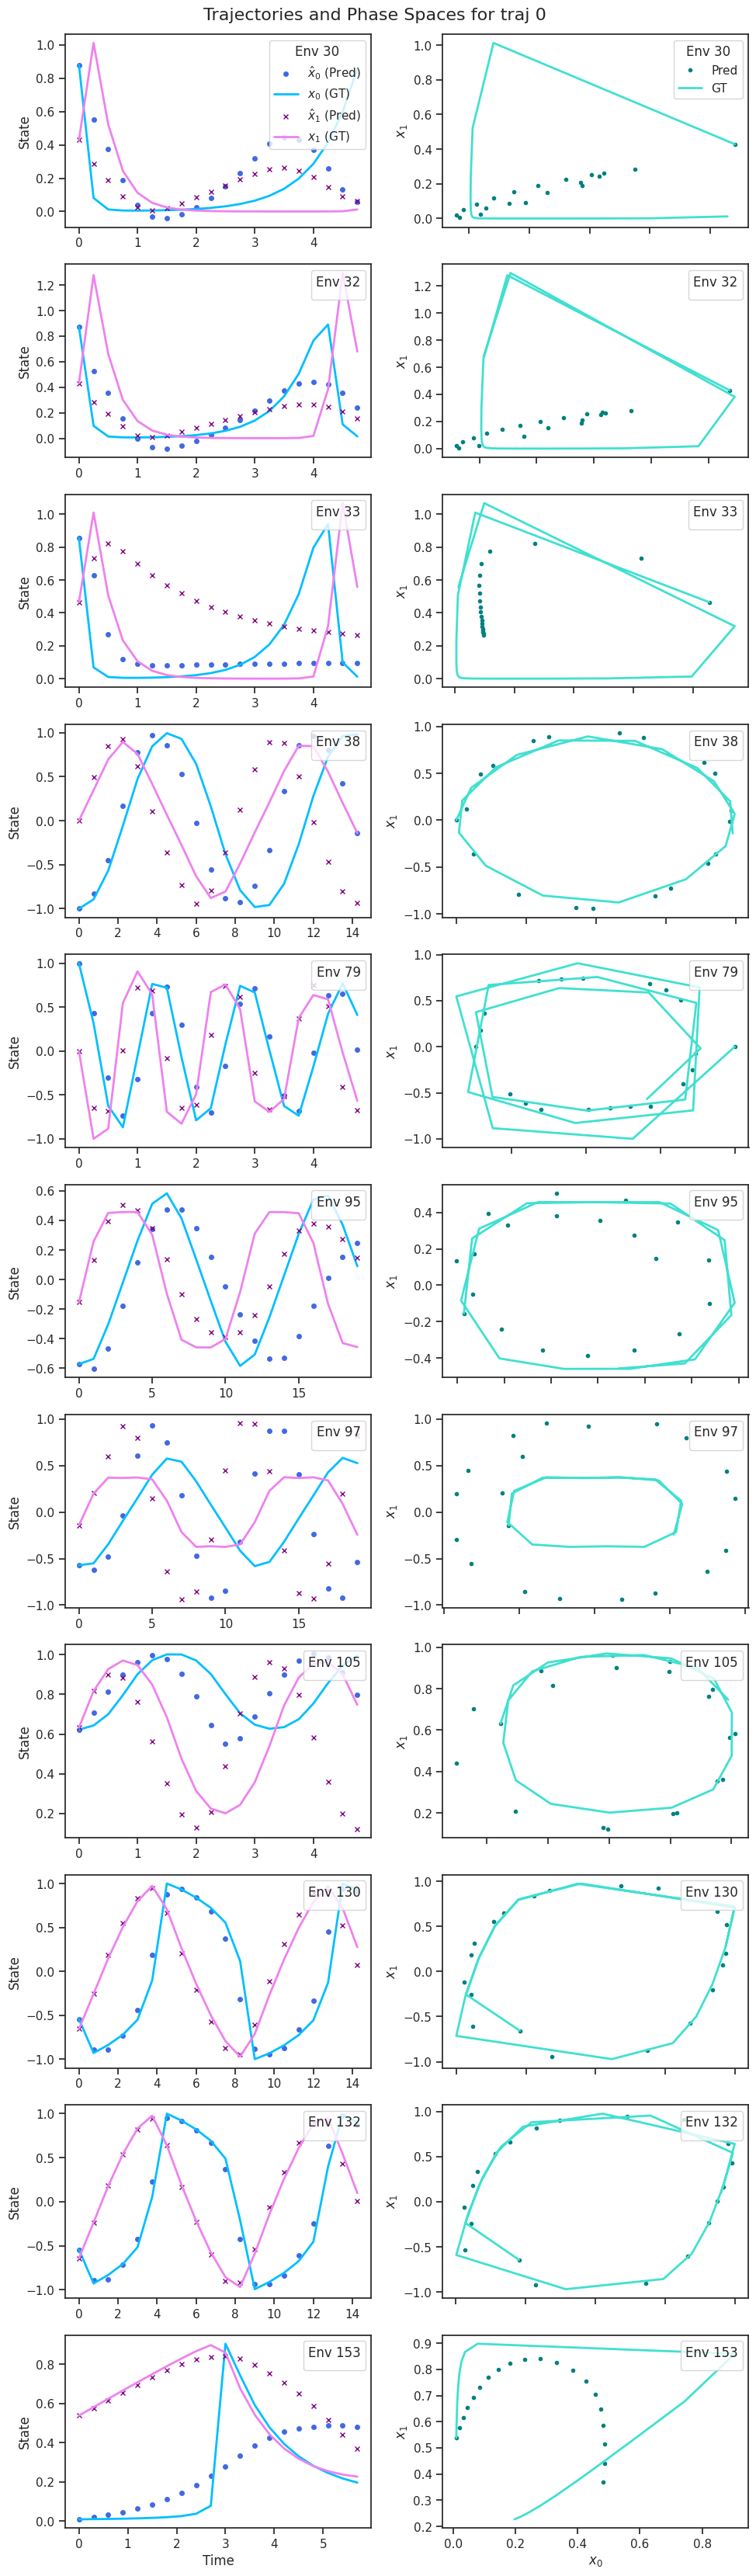

In [ ]:
#%%

visualtester.visualize_dynamics(save_path=run_folder+"dynamics.png",
                                data_loader=val_dataloader,
                                # nb_envs=10,
                                envs=[30, 32, 33, 38, 79, 95, 97, 105, 130, 132, 153],
                                traj=0,
                                share_axes=False,
                                key=test_key)